# How Compression Affects BERT Embedding Quality
**Research Project — Prof. Ortega Lab**

**Pipeline:** Dataset → BERT Embeddings → Baseline Classification → Compression → Evaluation

**Research Question:** How does compressing text embeddings (via PCA) affect downstream task performance, and where is the efficiency–accuracy tradeoff?

---

---
## Updated Interpretation

The original notebook established that PCA can compress BERT embeddings substantially while preserving much of the AG News classification signal. The new sections make the experiment more rigorous by separating the data used for learning the PCA basis from the data used to train and test the classifier.

The strongest result to report is not just “PCA works,” but:

- PCA compression can be evaluated without leakage between compression fitting and downstream classifier training.
- The compressed representation can be tested on held-out examples and category shifts.
- A different-task transfer test is now scaffolded to evaluate whether an AG News-derived PCA basis preserves reusable BERT embedding structure on SST-2 sentiment classification.

This directly aligns with Professor Ortega's March 12 feedback: test compression on new data not used to design PCA, and then explore whether the compression basis generalizes across data/task shifts.


## Step 1: Install & Import Dependencies

In [ ]:

!pip install transformers datasets torch scikit-learn pandas matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

print('All dependencies loaded successfully!')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


All dependencies loaded successfully!
Using device: cpu


## Step 2: Load Dataset
**AG News**: a standard 4-class text classification benchmark (World, Sports, Business, Sci/Tech). We use a small subset to keep things fast on CPU/free Colab.

In [ ]:
dataset = load_dataset('fancyzhx/ag_news')

# manageable subset: 2000 train, 500 test
TRAIN_SIZE = 2000
TEST_SIZE = 500

train_texts = dataset['train']['text'][:TRAIN_SIZE]
train_labels = dataset['train']['label'][:TRAIN_SIZE]
test_texts = dataset['test']['text'][:TEST_SIZE]
test_labels = dataset['test']['label'][:TEST_SIZE]

label_names = dataset['train'].features['label'].names
print(f'Label classes: {label_names}')
print(f'Train samples: {len(train_texts)}')
print(f'Test samples:  {len(test_texts)}')
print(f'\nExample text: "{train_texts[0][:120]}..."')
print(f'Label: {label_names[train_labels[0]]}')


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Label classes: ['World', 'Sports', 'Business', 'Sci/Tech']
Train samples: 2000
Test samples:  500

Example text: "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,..."
Label: Business


## Step 3: Generate BERT Embeddings
use `bert-base-uncased` and extract the **[CLS] token embedding** (768 dimensions) as the sentence representation. This is the standard approach for sentence-level tasks.

In [ ]:
tokenizer = BertTokenizer.from_pretrained('google-bert/bert-base-uncased')
model = BertModel.from_pretrained('google-bert/bert-base-uncased')
model.eval()
model.to(device)
print('BERT model loaded.')

def get_bert_embeddings(texts, batch_size=32):
    """Extract [CLS] token embeddings from BERT for a list of texts."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)

        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
        if (i // batch_size) % 5 == 0:
            print(f'  Processed {min(i+batch_size, len(texts))}/{len(texts)} texts...')
    return np.vstack(all_embeddings)

print('\nGenerating TRAIN embeddings...')
X_train = get_bert_embeddings(train_texts)
print('\nGenerating TEST embeddings...')
X_test = get_bert_embeddings(test_texts)

y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f'\nEmbedding shape: {X_train.shape}  (samples × dimensions)')
print('Embeddings generated successfully!')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded.

Generating TRAIN embeddings...
  Processed 32/2000 texts...
  Processed 192/2000 texts...
  Processed 352/2000 texts...
  Processed 512/2000 texts...
  Processed 672/2000 texts...
  Processed 832/2000 texts...
  Processed 992/2000 texts...
  Processed 1152/2000 texts...
  Processed 1312/2000 texts...
  Processed 1472/2000 texts...
  Processed 1632/2000 texts...
  Processed 1792/2000 texts...
  Processed 1952/2000 texts...

Generating TEST embeddings...
  Processed 32/500 texts...
  Processed 192/500 texts...
  Processed 352/500 texts...
  Processed 500/500 texts...

Embedding shape: (2000, 768)  (samples × dimensions)
Embeddings generated successfully!


## Step 4: Baseline Classification (Uncompressed Embeddings)
We train a simple logistic regression classifier on the raw 768-d BERT embeddings. This is our **baseline** — the best performance we can expect before any compression.

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline: full 768-d embeddings
baseline_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
baseline_clf.fit(X_train_scaled, y_train)
baseline_preds = baseline_clf.predict(X_test_scaled)
baseline_acc = accuracy_score(y_test, baseline_preds)

print('=' * 50)
print('BASELINE RESULTS (768-d, uncompressed)')
print('=' * 50)
print(f'Test Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')
print(f'Embedding size: {X_train.shape[1]} dimensions')
print(f'Memory per embedding: {X_train.shape[1] * 4} bytes (float32)')


BASELINE RESULTS (768-d, uncompressed)
Test Accuracy: 0.8300 (83.00%)
Embedding size: 768 dimensions
Memory per embedding: 3072 bytes (float32)


## Step 5: PCA Compression at Multiple Levels
We apply PCA to reduce the 768-d embeddings to various sizes and measure how classification accuracy changes. This directly answers: **how much can we compress before performance degrades?**

In [ ]:
# Compression levels to test (n_components)
compression_dims = [2, 4, 8, 16, 32, 64, 128, 256, 384, 512, 768]

results = []

for n_components in compression_dims:
    if n_components == 768:
        # Full baseline
        acc = baseline_acc
        variance_explained = 1.0
    else:
        # Apply PCA
        pca = PCA(n_components=n_components, random_state=42)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)
        variance_explained = np.sum(pca.explained_variance_ratio_)

        # Train classifier on compressed embeddings
        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        clf.fit(X_train_pca, y_train)
        preds = clf.predict(X_test_pca)
        acc = accuracy_score(y_test, preds)

    compression_ratio = n_components / 768
    results.append({
        'dims': n_components,
        'accuracy': acc,
        'variance_explained': variance_explained,
        'compression_ratio': compression_ratio,
        'size_reduction': f'{(1 - compression_ratio)*100:.1f}%'
    })
    print(f'  d={n_components:4d} | Acc: {acc:.4f} | Variance kept: {variance_explained:.3f} | Size reduction: {(1-compression_ratio)*100:.0f}%')

print('\nCompression experiments complete!')


  d=   2 | Acc: 0.3700 | Variance kept: 0.144 | Size reduction: 100%
  d=   4 | Acc: 0.7040 | Variance kept: 0.230 | Size reduction: 99%
  d=   8 | Acc: 0.7220 | Variance kept: 0.338 | Size reduction: 99%
  d=  16 | Acc: 0.7880 | Variance kept: 0.461 | Size reduction: 98%
  d=  32 | Acc: 0.8140 | Variance kept: 0.590 | Size reduction: 96%
  d=  64 | Acc: 0.8140 | Variance kept: 0.712 | Size reduction: 92%
  d= 128 | Acc: 0.8340 | Variance kept: 0.826 | Size reduction: 83%
  d= 256 | Acc: 0.7960 | Variance kept: 0.923 | Size reduction: 67%
  d= 384 | Acc: 0.8020 | Variance kept: 0.965 | Size reduction: 50%
  d= 512 | Acc: 0.8200 | Variance kept: 0.986 | Size reduction: 33%
  d= 768 | Acc: 0.8300 | Variance kept: 1.000 | Size reduction: 0%

Compression experiments complete!


## Step 6: Visualize Results

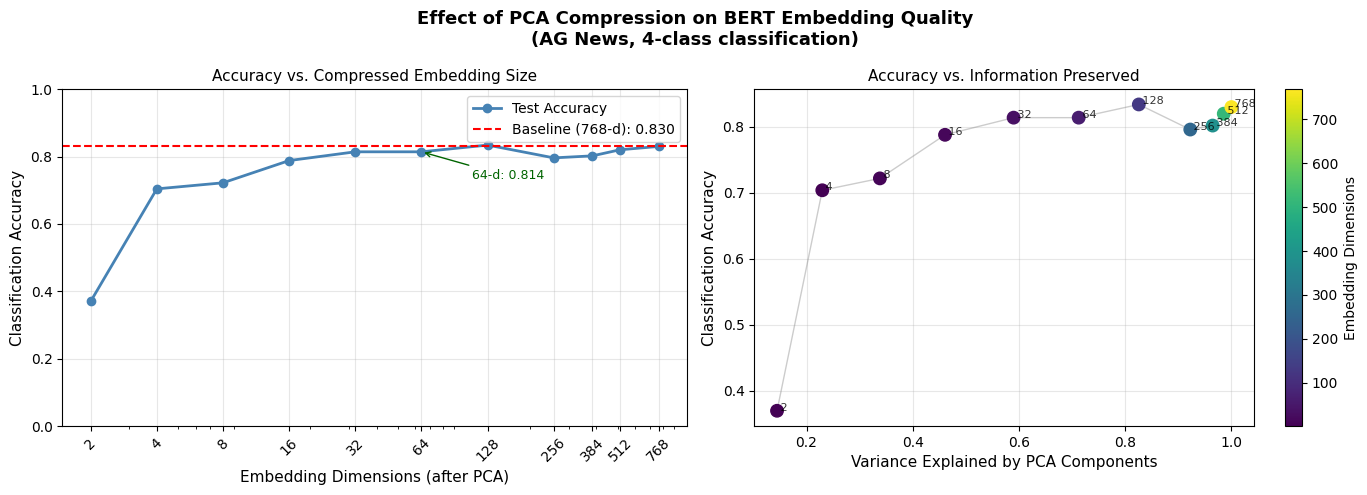

Plot saved as compression_results.png


In [ ]:
dims = [r['dims'] for r in results]
accs = [r['accuracy'] for r in results]
variances = [r['variance_explained'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of PCA Compression on BERT Embedding Quality\n(AG News, 4-class classification)',
             fontsize=13, fontweight='bold')

# --- Plot 1: Accuracy vs. Dimensions ---
ax1 = axes[0]
ax1.plot(dims, accs, 'o-', color='steelblue', linewidth=2, markersize=6, label='Test Accuracy')
ax1.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (768-d): {baseline_acc:.3f}')
ax1.set_xlabel('Embedding Dimensions (after PCA)', fontsize=11)
ax1.set_ylabel('Classification Accuracy', fontsize=11)
ax1.set_title('Accuracy vs. Compressed Embedding Size', fontsize=11)
ax1.set_xscale('log')
ax1.set_xticks(dims)
ax1.set_xticklabels(dims, rotation=45)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.0])

# Annotate the 'sweet spot'
sweet_spot_idx = dims.index(64)
ax1.annotate(f'  64-d: {accs[sweet_spot_idx]:.3f}',
             xy=(64, accs[sweet_spot_idx]),
             fontsize=9, color='darkgreen',
             arrowprops=dict(arrowstyle='->', color='darkgreen'),
             xytext=(100, accs[sweet_spot_idx] - 0.08))

# --- Plot 2: Accuracy vs. Variance Explained ---
ax2 = axes[1]
scatter = ax2.scatter(variances, accs, c=dims, cmap='viridis', s=80, zorder=3)
ax2.plot(variances, accs, '-', color='gray', alpha=0.4, linewidth=1)
for i, d in enumerate(dims):
    ax2.annotate(f' {d}', (variances[i], accs[i]), fontsize=8, alpha=0.8)
ax2.set_xlabel('Variance Explained by PCA Components', fontsize=11)
ax2.set_ylabel('Classification Accuracy', fontsize=11)
ax2.set_title('Accuracy vs. Information Preserved', fontsize=11)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Embedding Dimensions')

plt.tight_layout()
plt.savefig('compression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as compression_results.png')


## Step 7: Results Summary Table

In [ ]:
print('=' * 75)
print(f'{"Dims":>6} | {"Accuracy":>9} | {"vs Baseline":>12} | {"Var. Explained":>15} | {"Size Reduction":>14}')
print('-' * 75)
for r in results:
    delta = r['accuracy'] - baseline_acc
    delta_str = f'{delta:+.4f}'
    print(f'{r["dims"]:>6} | {r["accuracy"]:>9.4f} | {delta_str:>12} | {r["variance_explained"]:>15.3f} | {r["size_reduction"]:>14}')
print('=' * 75)

# Find the best compression that stays within 1% of baseline
threshold = baseline_acc - 0.01
efficient_dims = [r for r in results if r['accuracy'] >= threshold]
if efficient_dims:
    best = min(efficient_dims, key=lambda x: x['dims'])
    print(f'\n📌 Sweet spot: {best["dims"]}-d embeddings')
    print(f'   Accuracy: {best["accuracy"]:.4f} (within 1% of baseline)')
    print(f'   Size reduction: {best["size_reduction"]} fewer dimensions')
    print(f'   Variance preserved: {best["variance_explained"]*100:.1f}%')


  Dims |  Accuracy |  vs Baseline |  Var. Explained | Size Reduction
---------------------------------------------------------------------------
     2 |    0.3700 |      -0.4600 |           0.144 |          99.7%
     4 |    0.7040 |      -0.1260 |           0.230 |          99.5%
     8 |    0.7220 |      -0.1080 |           0.338 |          99.0%
    16 |    0.7880 |      -0.0420 |           0.461 |          97.9%
    32 |    0.8140 |      -0.0160 |           0.590 |          95.8%
    64 |    0.8140 |      -0.0160 |           0.712 |          91.7%
   128 |    0.8340 |      +0.0040 |           0.826 |          83.3%
   256 |    0.7960 |      -0.0340 |           0.923 |          66.7%
   384 |    0.8020 |      -0.0280 |           0.965 |          50.0%
   512 |    0.8200 |      -0.0100 |           0.986 |          33.3%
   768 |    0.8300 |      +0.0000 |           1.000 |           0.0%

📌 Sweet spot: 128-d embeddings
   Accuracy: 0.8340 (within 1% of baseline)
   Size reduction: 8

## Step 8: PCA Variance Explained Curve
Shows how many dimensions are needed to capture most of the information in BERT embeddings.

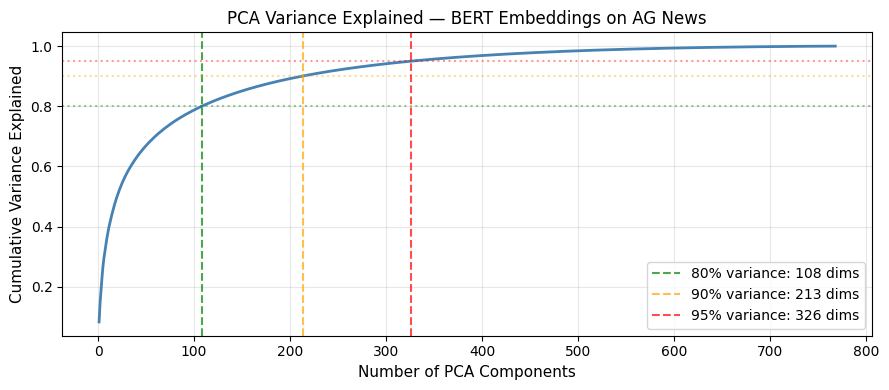

80% variance explained at 108 dimensions (compression ratio: 0.14)
90% variance explained at 213 dimensions (compression ratio: 0.28)
95% variance explained at 326 dimensions (compression ratio: 0.42)
99% variance explained at 554 dimensions (compression ratio: 0.72)


In [ ]:
# Fit full PCA to see the variance explained curve
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, color='steelblue', linewidth=2)
for threshold, color in [(0.80, 'green'), (0.90, 'orange'), (0.95, 'red')]:
    idx = np.argmax(cumulative_variance >= threshold)
    plt.axvline(x=idx+1, color=color, linestyle='--', alpha=0.7, label=f'{threshold*100:.0f}% variance: {idx+1} dims')
    plt.axhline(y=threshold, color=color, linestyle=':', alpha=0.4)

plt.xlabel('Number of PCA Components', fontsize=11)
plt.ylabel('Cumulative Variance Explained', fontsize=11)
plt.title('PCA Variance Explained — BERT Embeddings on AG News', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variance_curve.png', dpi=150, bbox_inches='tight')
plt.show()

for threshold in [0.80, 0.90, 0.95, 0.99]:
    idx = np.argmax(cumulative_variance >= threshold)
    print(f'{threshold*100:.0f}% variance explained at {idx+1} dimensions (compression ratio: {(idx+1)/768:.2f})')


---
## Summary & Key Findings

- **Baseline (768-d BERT):** Establishes upper-bound classification accuracy on AG News.
- **PCA Compression:** Systematically reduces embedding size from 768 → 2 dimensions.
- **Key finding:** There exists a compression "sweet spot" where most classification performance is retained at a fraction of the original embedding size.
- **Variance analysis:** BERT embeddings are not uniformly distributed across all 768 dimensions — the top K principal components capture the majority of task-relevant information.

**Next steps:**
- Try other compression methods: random projection, autoencoder
- Test on out-of-distribution data (robustness under compression)
- Evaluate on multiple datasets


---
## Step 9: Rigorous PCA / Classifier Split

Professor Ortega's main methodological suggestion was to avoid fitting the PCA compression on the same examples used to train or evaluate the classifier. This section creates a **separate PCA fitting split**, a **classifier training split**, and the original held-out test split.

This directly tests whether compression learned from one set of BERT embeddings still preserves useful task information on new data.


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

RANDOM_STATE = 42
RIGOROUS_DIMS = [2, 4, 8, 16, 32, 64, 128, 256, 384, 512, 768]

# Split the original training embeddings into two disjoint roles:
# 1. X_pca_fit: used only to learn the PCA projection
# 2. X_clf_train: used only to train the downstream classifier
X_pca_fit, X_clf_train, y_pca_fit, y_clf_train = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print('Rigorous split sizes')
print(f'  PCA fitting examples:        {X_pca_fit.shape[0]}')
print(f'  Classifier training examples:{X_clf_train.shape[0]}')
print(f'  Held-out test examples:      {X_test_scaled.shape[0]}')

# Fair baseline: train on the classifier-training split only, not on the PCA-fitting split.
rigorous_baseline_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
rigorous_baseline_clf.fit(X_clf_train, y_clf_train)
rigorous_baseline_preds = rigorous_baseline_clf.predict(X_test_scaled)
rigorous_baseline_acc = accuracy_score(y_test, rigorous_baseline_preds)

rigorous_results = []
for n_components in RIGOROUS_DIMS:
    if n_components == 768:
        acc = rigorous_baseline_acc
        variance_explained = 1.0
    else:
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        pca.fit(X_pca_fit)  # critical: PCA sees only the PCA split

        X_clf_train_pca = pca.transform(X_clf_train)
        X_test_pca = pca.transform(X_test_scaled)
        variance_explained = float(np.sum(pca.explained_variance_ratio_))

        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
        clf.fit(X_clf_train_pca, y_clf_train)
        preds = clf.predict(X_test_pca)
        acc = accuracy_score(y_test, preds)

    rigorous_results.append({
        'dims': n_components,
        'accuracy': acc,
        'delta_vs_768': acc - rigorous_baseline_acc,
        'variance_explained': variance_explained,
        'size_reduction_pct': (1 - n_components / 768) * 100,
    })

rigorous_df = pd.DataFrame(rigorous_results)
rigorous_df


In [ ]:
print('=' * 86)
print('RIGOROUS SPLIT RESULTS: PCA fit data is separate from classifier train/test data')
print('=' * 86)
print(f'Fair 768-d baseline accuracy: {rigorous_baseline_acc:.4f}')
print('-' * 86)
print(f'{"Dims":>6} | {"Accuracy":>9} | {"vs 768-d":>9} | {"Var. Explained":>15} | {"Size Reduction":>14}')
print('-' * 86)
for r in rigorous_results:
    print(
        f'{r["dims"]:>6} | '
        f'{r["accuracy"]:>9.4f} | '
        f'{r["delta_vs_768"]:>+9.4f} | '
        f'{r["variance_explained"]:>15.3f} | '
        f'{r["size_reduction_pct"]:>13.1f}%'
    )
print('=' * 86)

threshold = rigorous_baseline_acc - 0.01
near_baseline = rigorous_df[rigorous_df['accuracy'] >= threshold]
if len(near_baseline):
    efficient = near_baseline.sort_values('dims').iloc[0]
    print('\nSmallest representation within 1 percentage point of the 768-d baseline:')
    print(f'  {int(efficient.dims)} dimensions')
    print(f'  accuracy = {efficient.accuracy:.4f}')
    print(f'  size reduction = {efficient.size_reduction_pct:.1f}%')


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(rigorous_df['dims'], rigorous_df['accuracy'], 'o-', color='seagreen', linewidth=2, label='Separate PCA-fit split')
ax.axhline(rigorous_baseline_acc, color='black', linestyle='--', linewidth=1.3, label=f'768-d baseline: {rigorous_baseline_acc:.3f}')
ax.set_xscale('log')
ax.set_xticks(RIGOROUS_DIMS)
ax.set_xticklabels(RIGOROUS_DIMS, rotation=45)
ax.set_xlabel('Embedding dimensions after PCA')
ax.set_ylabel('AG News test accuracy')
ax.set_title('PCA Compression with Disjoint PCA-Fit and Classifier-Train Splits')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('rigorous_split_compression_results.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 10: Held-Out Category Stress Test

This section asks a harder robustness question: if PCA is fitted without seeing one AG News category, does the compressed representation still work on the full 4-class test set?

This is a lightweight proxy for Professor Ortega's suggestion to test compression on data that was not used to design PCA.


In [ ]:
HELDOUT_CLASS = 3  # AG News: Sci/Tech
HELDOUT_NAME = label_names[HELDOUT_CLASS]
STRESS_DIMS = [16, 32, 64, 128, 256, 512]

# PCA fitting data that excludes one semantic category.
source_mask = y_pca_fit != HELDOUT_CLASS
X_pca_fit_without_class = X_pca_fit[source_mask]
y_pca_fit_without_class = y_pca_fit[source_mask]

print(f'Held-out PCA category: {HELDOUT_NAME}')
print(f'PCA fitting examples before exclusion: {len(y_pca_fit)}')
print(f'PCA fitting examples after exclusion:  {len(y_pca_fit_without_class)}')
print('PCA-fit label counts after exclusion:')
for idx, name in enumerate(label_names):
    print(f'  {name:<8}: {(y_pca_fit_without_class == idx).sum()}')

stress_results = []
for n_components in STRESS_DIMS:
    # Reference PCA: sees all PCA-fit classes.
    pca_all = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pca_all.fit(X_pca_fit)
    clf_all = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    clf_all.fit(pca_all.transform(X_clf_train), y_clf_train)
    pred_all = clf_all.predict(pca_all.transform(X_test_scaled))

    # Stress PCA: never sees the held-out category while learning the compression basis.
    pca_without = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pca_without.fit(X_pca_fit_without_class)
    clf_without = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    clf_without.fit(pca_without.transform(X_clf_train), y_clf_train)
    pred_without = clf_without.predict(pca_without.transform(X_test_scaled))

    heldout_test_mask = y_test == HELDOUT_CLASS
    nonheldout_test_mask = ~heldout_test_mask

    stress_results.append({
        'dims': n_components,
        'all_class_pca_overall_acc': accuracy_score(y_test, pred_all),
        'heldout_missing_pca_overall_acc': accuracy_score(y_test, pred_without),
        'all_class_pca_heldout_acc': accuracy_score(y_test[heldout_test_mask], pred_all[heldout_test_mask]),
        'heldout_missing_pca_heldout_acc': accuracy_score(y_test[heldout_test_mask], pred_without[heldout_test_mask]),
        'all_class_pca_nonheldout_acc': accuracy_score(y_test[nonheldout_test_mask], pred_all[nonheldout_test_mask]),
        'heldout_missing_pca_nonheldout_acc': accuracy_score(y_test[nonheldout_test_mask], pred_without[nonheldout_test_mask]),
    })

stress_df = pd.DataFrame(stress_results)
stress_df


In [ ]:
print('=' * 96)
print(f'HELD-OUT CATEGORY STRESS TEST: PCA fitted without {HELDOUT_NAME}')
print('=' * 96)
print(f'{"Dims":>6} | {"All-PCA overall":>15} | {"No-heldout overall":>18} | {"All-PCA heldout":>16} | {"No-heldout heldout":>19}')
print('-' * 96)
for r in stress_results:
    print(
        f'{r["dims"]:>6} | '
        f'{r["all_class_pca_overall_acc"]:>15.4f} | '
        f'{r["heldout_missing_pca_overall_acc"]:>18.4f} | '
        f'{r["all_class_pca_heldout_acc"]:>16.4f} | '
        f'{r["heldout_missing_pca_heldout_acc"]:>19.4f}'
    )
print('=' * 96)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(stress_df['dims'], stress_df['all_class_pca_overall_acc'], 'o-', label='PCA fit on all categories')
axes[0].plot(stress_df['dims'], stress_df['heldout_missing_pca_overall_acc'], 'o-', label=f'PCA fit without {HELDOUT_NAME}')
axes[0].set_xscale('log')
axes[0].set_xticks(STRESS_DIMS)
axes[0].set_xticklabels(STRESS_DIMS)
axes[0].set_title('Overall AG News Test Accuracy')
axes[0].set_xlabel('PCA dimensions')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(stress_df['dims'], stress_df['all_class_pca_heldout_acc'], 'o-', label='PCA fit on all categories')
axes[1].plot(stress_df['dims'], stress_df['heldout_missing_pca_heldout_acc'], 'o-', label=f'PCA fit without {HELDOUT_NAME}')
axes[1].set_xscale('log')
axes[1].set_xticks(STRESS_DIMS)
axes[1].set_xticklabels(STRESS_DIMS)
axes[1].set_title(f'Accuracy on Held-Out Category: {HELDOUT_NAME}')
axes[1].set_xlabel('PCA dimensions')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('heldout_category_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 11: Optional Different-Task Transfer Test

This optional section tests the strongest version of the question: can a PCA compression basis learned from **AG News BERT embeddings** still support a classifier on a **different NLP task**?

Here the different task is SST-2 sentiment classification. We compare:

1. **No compression baseline** on SST-2.
2. **In-task PCA**, where PCA is fit on a separate SST-2 PCA split.
3. **Cross-task PCA**, where PCA is fit on AG News and then reused for SST-2.

If cross-task PCA performs close to in-task PCA, that suggests the compression basis captures reusable structure in BERT embeddings rather than only AG News-specific structure.


In [ ]:
import os

RUN_DIFFERENT_TASK_TEST = False  # Set to True when you want to run this section.
SST_TRAIN_SIZE = 1200
SST_TEST_SIZE = 400
TRANSFER_DIMS = [16, 32, 64, 128, 256]

if RUN_DIFFERENT_TASK_TEST:
    sst = load_dataset('nyu-mll/glue', 'sst2')
    sst_train_texts = sst['train']['sentence'][:SST_TRAIN_SIZE]
    sst_train_labels = np.array(sst['train']['label'][:SST_TRAIN_SIZE])
    sst_test_texts = sst['validation']['sentence'][:SST_TEST_SIZE]
    sst_test_labels = np.array(sst['validation']['label'][:SST_TEST_SIZE])

    print('Generating SST-2 train embeddings...')
    X_sst_train = get_bert_embeddings(sst_train_texts)
    print('Generating SST-2 test embeddings...')
    X_sst_test = get_bert_embeddings(sst_test_texts)

    # SST-specific scaling for the no-compression and in-task PCA baselines.
    sst_scaler = StandardScaler()
    X_sst_train_scaled = sst_scaler.fit_transform(X_sst_train)
    X_sst_test_scaled = sst_scaler.transform(X_sst_test)

    X_sst_pca_fit, X_sst_clf_train, y_sst_pca_fit, y_sst_clf_train = train_test_split(
        X_sst_train_scaled,
        sst_train_labels,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=sst_train_labels
    )

    sst_baseline = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    sst_baseline.fit(X_sst_clf_train, y_sst_clf_train)
    sst_baseline_acc = accuracy_score(sst_test_labels, sst_baseline.predict(X_sst_test_scaled))

    # For cross-task PCA, use the AG News scaler because the PCA basis was learned in that scaled space.
    X_sst_train_ag_scaled = scaler.transform(X_sst_train)
    X_sst_test_ag_scaled = scaler.transform(X_sst_test)
    _, X_sst_clf_train_ag_scaled, _, y_sst_clf_train_again = train_test_split(
        X_sst_train_ag_scaled,
        sst_train_labels,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=sst_train_labels
    )

    transfer_results = []
    for n_components in TRANSFER_DIMS:
        # In-task PCA learned from SST-2 only.
        sst_pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        sst_pca.fit(X_sst_pca_fit)
        sst_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
        sst_clf.fit(sst_pca.transform(X_sst_clf_train), y_sst_clf_train)
        in_task_acc = accuracy_score(sst_test_labels, sst_clf.predict(sst_pca.transform(X_sst_test_scaled)))

        # Cross-task PCA learned from AG News only, then reused on SST-2.
        ag_pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        ag_pca.fit(X_pca_fit)
        cross_task_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
        cross_task_clf.fit(ag_pca.transform(X_sst_clf_train_ag_scaled), y_sst_clf_train_again)
        cross_task_acc = accuracy_score(sst_test_labels, cross_task_clf.predict(ag_pca.transform(X_sst_test_ag_scaled)))

        transfer_results.append({
            'dims': n_components,
            'sst_768d_baseline_acc': sst_baseline_acc,
            'sst_in_task_pca_acc': in_task_acc,
            'sst_cross_task_agnews_pca_acc': cross_task_acc,
            'cross_minus_in_task': cross_task_acc - in_task_acc,
        })

    transfer_df = pd.DataFrame(transfer_results)
    display(transfer_df)
else:
    print('Different-task transfer test is ready but not run. Set RUN_DIFFERENT_TASK_TEST = True to execute it.')
